# Задание 2 — Прогноз дебита

In [1]:
import os, io, warnings
import boto3
import pyarrow.parquet as pq
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')

PG_URI = (
    f"postgresql+psycopg2://"
    f"{os.getenv('PG_USER','oilfield')}:{os.getenv('PG_PASSWORD','oilfield123')}"
    f"@{os.getenv('PG_HOST','postgres')}:{os.getenv('PG_PORT','5432')}"
    f"/{os.getenv('PG_DB','oilfield')}"
)
MINIO_ENDPOINT   = os.getenv('MINIO_ENDPOINT',   'http://minio:9000')
MINIO_ACCESS_KEY = os.getenv('MINIO_ACCESS_KEY', 'minioadmin')
MINIO_SECRET_KEY = os.getenv('MINIO_SECRET_KEY', 'minioadmin123')
BUCKET           = os.getenv('MINIO_BUCKET',     'oilfield')

engine = create_engine(PG_URI)

s3 = boto3.client(
    's3',
    endpoint_url=MINIO_ENDPOINT,
    aws_access_key_id=MINIO_ACCESS_KEY,
    aws_secret_access_key=MINIO_SECRET_KEY,
)

def read_parquet(bucket, prefix):
    resp = s3.list_objects_v2(Bucket=bucket, Prefix=prefix)
    frames = []
    for obj in resp.get('Contents', []):
        if obj['Key'].endswith('.parquet'):
            buf = io.BytesIO()
            s3.download_fileobj(bucket, obj['Key'], buf)
            buf.seek(0)
            frames.append(pq.read_table(buf).to_pandas())
    return pd.concat(frames, ignore_index=True)

## 1. Загрузка данных

In [2]:
prod_df  = read_parquet(BUCKET, 'production/production.parquet')
wells_df = read_parquet(BUCKET, 'wells/wells.parquet')

prod_df['date'] = pd.to_datetime(prod_df['date'])
df = prod_df.merge(wells_df[['well_id', 'name']], on='well_id')
df = df[df['oil_ton'] > 0].dropna(subset=['temperature', 'pressure', 'energy_kwh', 'gas_m3', 'oil_ton'])

print(f'Dataset: {df.shape}')
display(df.head())


Dataset: (120, 11)


,prod_id,well_id,date,oil_ton,gas_m3,water_m3,energy_kwh,downtime_hours,temperature,pressure,name
0,1,1,2025-10-01,212.4,55200.0,182.3,7450.0,0.5,88.1,120.4,Well-101
1,2,1,2025-10-02,213.8,55320.0,181.9,7490.0,0.3,87.8,121.0,Well-101
2,3,1,2025-10-03,211.9,55040.0,183.2,7430.0,0.7,88.5,119.8,Well-101
3,4,1,2025-10-04,215.1,55500.0,180.5,7515.0,0.2,87.6,121.5,Well-101
4,5,1,2025-10-05,214.6,55380.0,182.0,7480.0,0.4,88.0,120.9,Well-101


## 2. EDA — корреляция признаков

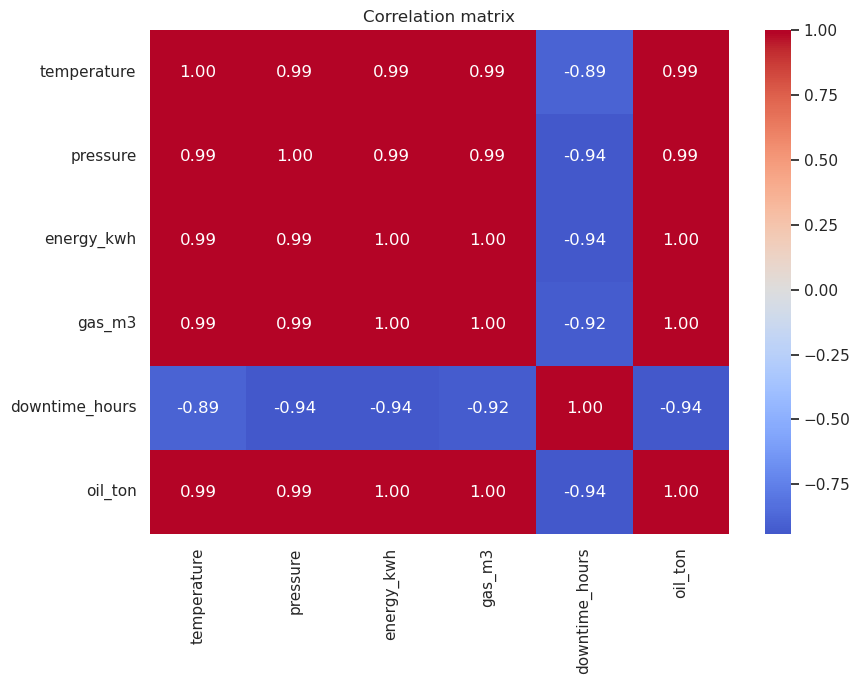

In [3]:
FEATURE_COLS = ['temperature', 'pressure', 'energy_kwh', 'gas_m3', 'downtime_hours']
TARGET_COL   = 'oil_ton'

corr = df[FEATURE_COLS + [TARGET_COL]].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation matrix')
plt.tight_layout()
plt.show()


## 3. Подготовка данных

In [4]:
X = df[FEATURE_COLS].values
y = df[TARGET_COL].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Train: 96 | Test: 24


## 4. Linear Regression

In [5]:
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print('Linear Regression')
print(f'MAE:  {mae_lr:.4f}  RMSE: {rmse_lr:.4f}  R2: {r2_lr:.4f}')

Linear Regression
MAE:  0.3590  RMSE: 0.4111  R2: 0.9999


## 5. Random Forest

In [6]:
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print('Random Forest')
print(f'MAE:  {mae_rf:.4f}  RMSE: {rmse_rf:.4f}  R2: {r2_rf:.4f}')

Random Forest
MAE:  0.2746  RMSE: 0.4477  R2: 0.9998


## 6. Сравнение моделей

,Model,MAE,RMSE,R2
0,LinearRegression,0.3590,0.4111,0.9999
1,RandomForest,0.2746,0.4477,0.9998


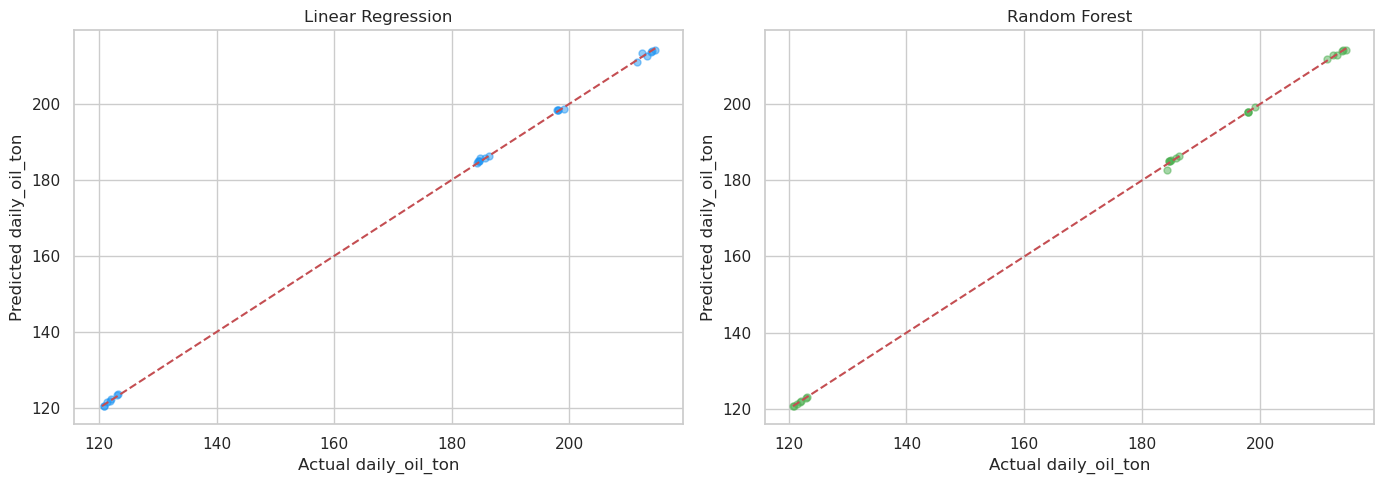

In [7]:
metrics_df = pd.DataFrame({
    'Model': ['LinearRegression', 'RandomForest'],
    'MAE':   [mae_lr, mae_rf],
    'RMSE':  [rmse_lr, rmse_rf],
    'R2':    [r2_lr, r2_rf],
})
display(metrics_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_pred, label, color in [
    (axes[0], y_pred_lr, 'Linear Regression', '#2196F3'),
    (axes[1], y_pred_rf, 'Random Forest',      '#4CAF50'),
]:
    ax.scatter(y_test, y_pred, alpha=0.5, s=25, color=color)
    mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5)
    ax.set_xlabel('Actual daily_oil_ton')
    ax.set_ylabel('Predicted daily_oil_ton')
    ax.set_title(label)
plt.tight_layout()
plt.show()

## 7. Feature Importance

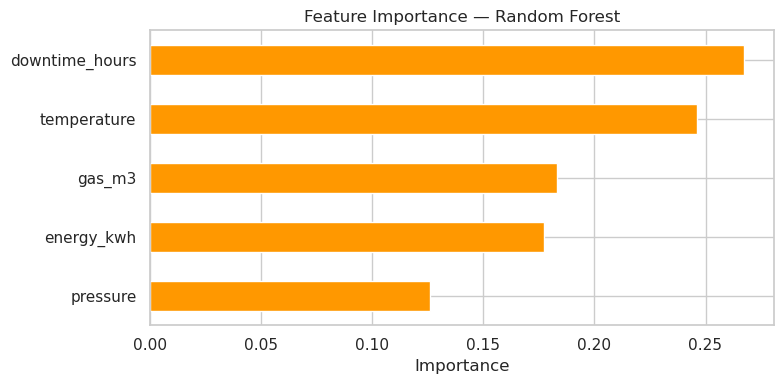

In [8]:
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 4))
importances.plot(kind='barh', ax=ax, color='#FF9800')
ax.set_title('Feature Importance — Random Forest')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 8. Сохранение в PostgreSQL

In [9]:
metrics_df.to_sql('analytics_model_metrics', engine, if_exists='replace', index=False)
print(f'Saved metrics to analytics_model_metrics')

Saved metrics to analytics_model_metrics
